# 07 ONNX Runtime Validation and Latency - finetune_v1

06 노트북에서는 fine-tuned CLRKDNet을 ONNX로 export했고, dummy input 기준 PyTorch/ONNX raw output parity를 확인했다.

이번 07 노트북의 목적은 한 단계 더 실제 런타임에 가깝게 확인하는 것이다.

1. 실제 holdout 이미지에서 ONNX Runtime 추론이 되는지 확인한다.
2. ONNX raw output이 PyTorch forward cache와 거의 같은지 확인한다.
3. ONNX raw output을 공식 `get_lanes()` decode에 넣어 lane 후보를 복원한다.
4. 05 노트북에서 정한 driving postprocess config를 적용해 `center_x`, `mode`, `confidence`를 만든다.
5. 로컬 CPU 기준 latency를 측정해 Pi 테스트 전 기준선을 잡는다.

중요한 점: ONNX 모델은 조향값을 직접 내지 않는다. 출력은 `[1, 192, 78]` raw lane prediction이고, 실제 주행 판단은 Python 후처리 코드가 담당한다.

## 0. 경로와 실행 설정

이 노트북은 local VSCode `<env>` kernel에서 실행하는 것을 기준으로 한다.

`EVAL_LIMIT = None`이면 holdout 전체 722장을 대상으로 ONNX 추론과 driving postprocess를 수행한다. 너무 오래 걸리면 우선 120 정도로 줄여서 smoke test를 해도 된다.

In [1]:
from pathlib import Path
import sys
import os
import json
import pickle
import time
from dataclasses import dataclass, asdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import onnxruntime as ort

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '06_lane_model_finetuning'

EXPORT_DIR = EXP_ROOT / 'model_exports' / 'finetune_v1'
ONNX_PATH = EXPORT_DIR / 'maplane_finetune_v1_fp32_raw.onnx'
EXPORT_META_PATH = EXPORT_DIR / 'maplane_finetune_v1_export_meta.json'
RUNTIME_POSTPROCESS_CONFIG_PATH = EXPORT_DIR / 'maplane_finetune_v1_driving_postprocess_config.json'

PREV_REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '03_official_lane_detector_postprocess_review_finetune_v1'
FORWARD_CACHE_PATH = PREV_REVIEW_ROOT / 'finetuned_forward_cache_full_holdout.pkl'

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '07_onnx_runtime_validation_and_latency'
TABLE_DIR = REVIEW_ROOT / 'tables'
OVERLAY_DIR = REVIEW_ROOT / 'overlays'
CACHE_DIR = REVIEW_ROOT / 'cache'
for p in [REVIEW_ROOT, TABLE_DIR, OVERLAY_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

RAW_W = 1296
RAW_H = 972
CUT_HEIGHT = 445
VISIBLE_H = RAW_H - CUT_HEIGHT
IMAGE_CENTER_X = RAW_W / 2

# None이면 holdout 전체. 빠른 smoke만 볼 때는 120 정도로 낮춰도 됨.
EVAL_LIMIT = None
PARITY_SAMPLE_COUNT = 80
LATENCY_RUNS = 100
LATENCY_WARMUP = 10
ORT_THREADS = 4
RANDOM_SEED = 0


def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def path_exists(path):
    return Path(win_long_path(path)).exists()


def read_text_any(path, encoding='utf-8'):
    with open(win_long_path(path), 'r', encoding=encoding) as f:
        return f.read()


def cv2_imread_color(path):
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


print('EXP_ROOT:', EXP_ROOT)
print('ONNX_PATH exists:', path_exists(ONNX_PATH), ONNX_PATH)
print('EXPORT_META_PATH exists:', path_exists(EXPORT_META_PATH), EXPORT_META_PATH)
print('POSTPROCESS_CONFIG exists:', path_exists(RUNTIME_POSTPROCESS_CONFIG_PATH), RUNTIME_POSTPROCESS_CONFIG_PATH)
print('FORWARD_CACHE_PATH exists:', path_exists(FORWARD_CACHE_PATH), FORWARD_CACHE_PATH)
print('REVIEW_ROOT:', REVIEW_ROOT)

assert path_exists(ONNX_PATH), ONNX_PATH
assert path_exists(EXPORT_META_PATH), EXPORT_META_PATH
assert path_exists(RUNTIME_POSTPROCESS_CONFIG_PATH), RUNTIME_POSTPROCESS_CONFIG_PATH
assert path_exists(FORWARD_CACHE_PATH), FORWARD_CACHE_PATH

EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning
ONNX_PATH exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\model_exports\finetune_v1\maplane_finetune_v1_fp32_raw.onnx
EXPORT_META_PATH exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\model_exports\finetune_v1\maplane_finetune_v1_export_meta.json
POSTPROCESS_CONFIG exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\model_exports\finetune_v1\maplane_finetune_v1_driving_postprocess_config.json
FORWARD_CACHE_PATH exists: True ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\03_official_lane_detector_postprocess_review_finetune_v1\finetuned_forward_cache_full_holdout.pkl
REVIEW_ROOT: ~\02_Projec

## 1. Export metadata와 runtime config 확인

06에서 저장한 metadata를 읽어 ONNX 입출력 의미와 05에서 선택한 driving postprocess 값을 다시 확인한다.

In [2]:
export_meta = json.loads(read_text_any(EXPORT_META_PATH))
runtime_pp_cfg = json.loads(read_text_any(RUNTIME_POSTPROCESS_CONFIG_PATH))

print('ONNX size MB:', export_meta.get('onnx_size_mb'))
print('input:', export_meta.get('input'))
print('output:', export_meta.get('output'))
print('06 dummy parity:', export_meta.get('parity'))
print('\nRuntime postprocess config:')
print(json.dumps(runtime_pp_cfg, indent=2, ensure_ascii=False))

ONNX size MB: 43.947
input: {'name': 'image', 'shape': [1, 3, 320, 800], 'dtype': 'float32', 'color_order': 'BGR', 'normalization': 'none'}
output: {'name': 'raw_predictions', 'shape': [1, 192, 78], 'meaning': 'CLRKDNet raw head prediction. Lane decode and driving postprocess are performed in Python runtime.'}
06 dummy parity: {'max_abs_diff': 1.9073486328125e-06, 'mean_abs_diff': 6.825537468557741e-08, 'p95_abs_diff': 1.9371509552001953e-07}

Runtime postprocess config:
{
  "detector_name": "conf0.25_nms70_max4",
  "lookahead_profile": "single_085",
  "min_lane_points": 6,
  "min_y_span": 100.0,
  "max_y_distance": 60.0,
  "duplicate_x_px": 40.0,
  "pair_policy": "quality_first",
  "gap_min_scale": 0.55,
  "gap_max_scale": 1.9,
  "one_lane_offset_scale": 0.5,
  "one_lane_policy": "center_nearest",
  "center_policy": "primary",
  "runtime_policy_note": "both lane normal speed; left_only/right_only should use lower confidence and reduced speed; lost should slow/stop after short hold."
}

## 2. Holdout forward cache 로딩

03 노트북에서 만들어 둔 `finetuned_forward_cache_full_holdout.pkl`에는 holdout 이미지 경로, pseudo GT, PyTorch raw output이 들어 있다.

여기서는 같은 이미지들을 ONNX Runtime으로 다시 추론하고, cached PyTorch raw output과 비교한다. 이 비교가 작으면 “실제 이미지에서도 ONNX 변환이 깨지지 않았다”고 볼 수 있다.

In [3]:
with open(win_long_path(FORWARD_CACHE_PATH), 'rb') as f:
    forward_cache = pickle.load(f)

all_samples = forward_cache['samples']
print('cached samples:', len(all_samples))
print('cache settings:', forward_cache.get('settings', {}).keys())

missing = []
for s in all_samples[:20]:
    if not path_exists(s['img_path']):
        missing.append(s['img_path'])
print('first 20 missing images:', len(missing))
if missing:
    print(missing[:5])
assert not missing, '일부 이미지 경로가 존재하지 않음. dataset 경로 정리 필요.'

if EVAL_LIMIT is None:
    samples = list(all_samples)
else:
    samples = list(all_samples[:int(EVAL_LIMIT)])

print('EVAL_LIMIT:', EVAL_LIMIT)
print('samples used:', len(samples))
display(pd.DataFrame([{'index': s['index'], 'scene': s['scene'], 'file': Path(s['rel']).name} for s in samples[:12]]))

cached samples: 722
cache settings: dict_keys(['checkpoint', 'eval_rels', 'config'])
first 20 missing images: 0
EVAL_LIMIT: None
samples used: 722


,index,scene,file
0,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...
1,1,field1_sign_background,20260430_175025_signs_background_moving_mixed_...
2,2,field1_sign_background,20260430_175025_signs_background_moving_mixed_...
3,3,field1_sign_background,20260430_175025_signs_background_moving_mixed_...
4,4,field1_sign_background,20260430_175025_signs_background_moving_mixed_...
5,5,field1_sign_background,20260430_175026_signs_background_moving_mixed_...
6,6,field1_sign_background,20260430_175026_signs_background_moving_mixed_...
7,7,field1_sign_background,20260430_175026_signs_background_moving_mixed_...
8,8,field1_sign_background,20260430_175026_signs_background_moving_mixed_...
9,9,field1_sign_background,20260430_175026_signs_background_moving_mixed_...


## 3. ONNX Runtime session 생성

Pi에서는 ONNX Runtime CPU provider를 사용할 예정이므로, local에서도 CPU provider 기준으로 먼저 확인한다.  
로컬 latency는 Pi latency와 다르지만, export가 정상인지와 postprocess 연결이 되는지는 충분히 검증할 수 있다.

In [4]:
so = ort.SessionOptions()
so.intra_op_num_threads = ORT_THREADS
so.inter_op_num_threads = 1
so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(str(ONNX_PATH), sess_options=so, providers=['CPUExecutionProvider'])
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

print('providers:', session.get_providers())
print('input:', input_name, session.get_inputs()[0].shape, session.get_inputs()[0].type)
print('output:', output_name, session.get_outputs()[0].shape, session.get_outputs()[0].type)

providers: ['CPUExecutionProvider']
input: image [1, 3, 320, 800] tensor(float)
output: raw_predictions [1, 192, 78] tensor(float)


## 4. 실제 이미지 전처리와 ONNX 추론 함수

전처리는 03/06 노트북과 동일하게 맞춘다.

- raw BGR 이미지 사용
- 위쪽 `cut_height=445` 제거
- `800x320` resize
- `float32 / 255.0`
- `NCHW` tensor

In [5]:
def preprocess_bgr_for_onnx(img_bgr):
    crop = img_bgr[CUT_HEIGHT:, :, :]
    resized = cv2.resize(crop, (800, 320), interpolation=cv2.INTER_CUBIC)
    tensor = resized.astype(np.float32) / 255.0
    tensor = np.transpose(tensor, (2, 0, 1))[None, ...]
    return np.ascontiguousarray(tensor), resized


def run_onnx_image(image_path):
    img_bgr = cv2_imread_color(image_path)
    if img_bgr is None:
        raise RuntimeError(f'failed to read image: {image_path}')
    t0 = time.perf_counter()
    tensor, resized_bgr = preprocess_bgr_for_onnx(img_bgr)
    t1 = time.perf_counter()
    output = session.run([output_name], {input_name: tensor})[0]
    t2 = time.perf_counter()
    return {
        'raw_bgr': img_bgr,
        'model_bgr': resized_bgr,
        'tensor': tensor,
        'output': output,
        'preprocess_ms': (t1 - t0) * 1000,
        'onnx_ms': (t2 - t1) * 1000,
        'total_ms': (t2 - t0) * 1000,
    }


sample0 = samples[0]
out0 = run_onnx_image(sample0['img_path'])
print('sample:', sample0['scene'], Path(sample0['rel']).name)
print('tensor:', out0['tensor'].shape, out0['tensor'].dtype, out0['tensor'].min(), out0['tensor'].max())
print('onnx output:', out0['output'].shape, out0['output'].dtype)
print('timing ms:', {k: round(out0[k], 3) for k in ['preprocess_ms', 'onnx_ms', 'total_ms']})

sample: field1_sign_background 20260430_175024_signs_background_moving_mixed_right_0001.jpg
tensor: (1, 3, 320, 800) float32 0.047058824 0.8117647
onnx output: (1, 192, 78) float32
timing ms: {'preprocess_ms': 25.656, 'onnx_ms': 117.698, 'total_ms': 143.354}


## 5. 실제 이미지 기준 PyTorch cache vs ONNX raw output parity

06의 dummy parity는 “export 수학식이 깨지지 않았다”는 확인이었다.  
이번에는 실제 map 이미지들을 넣고 PyTorch cache와 ONNX output을 비교한다.

In [6]:
def evenly_spaced_indices(n, count):
    count = min(int(count), int(n))
    if count <= 0:
        return []
    return np.linspace(0, n - 1, count).round().astype(int).tolist()


parity_indices = evenly_spaced_indices(len(samples), PARITY_SAMPLE_COUNT)
parity_rows = []

for k, sample_idx in enumerate(parity_indices, start=1):
    sample = samples[sample_idx]
    result = run_onnx_image(sample['img_path'])
    onnx_raw = result['output']
    torch_raw = sample['raw_output'].detach().cpu().numpy()
    diff = np.abs(onnx_raw - torch_raw)
    parity_rows.append({
        'sample_index': sample['index'],
        'scene': sample['scene'],
        'file': Path(sample['rel']).name,
        'max_abs_diff': float(np.max(diff)),
        'mean_abs_diff': float(np.mean(diff)),
        'p95_abs_diff': float(np.quantile(diff, 0.95)),
        'preprocess_ms': result['preprocess_ms'],
        'onnx_ms': result['onnx_ms'],
        'total_ms': result['total_ms'],
    })
    if k == 1 or k % 20 == 0 or k == len(parity_indices):
        print(f'parity {k}/{len(parity_indices)} max={parity_rows[-1]["max_abs_diff"]:.3e} onnx_ms={result["onnx_ms"]:.2f}')

parity_df = pd.DataFrame(parity_rows)
PARITY_CSV = TABLE_DIR / 'actual_image_onnx_pytorch_raw_parity.csv'
parity_df.to_csv(win_long_path(PARITY_CSV), index=False, encoding='utf-8-sig')

summary = parity_df[['max_abs_diff', 'mean_abs_diff', 'p95_abs_diff', 'preprocess_ms', 'onnx_ms', 'total_ms']].describe(percentiles=[0.5, 0.9, 0.95])
display(summary)
print('saved:', PARITY_CSV)

parity 1/80 max=2.384e-06 onnx_ms=117.82
parity 20/80 max=1.059e-04 onnx_ms=50.65
parity 40/80 max=1.812e-04 onnx_ms=53.23
parity 60/80 max=7.153e-06 onnx_ms=51.51
parity 80/80 max=3.338e-06 onnx_ms=51.37


,max_abs_diff,mean_abs_diff,p95_abs_diff,preprocess_ms,onnx_ms,total_ms
count,80.000000,8.000000e+01,8.000000e+01,80.000000,80.000000,80.000000
mean,0.018030,4.378251e-05,7.399940e-07,3.886943,55.925365,59.812308
std,0.152385,3.706610e-04,1.498482e-06,0.381977,9.461614,9.476660
min,0.000002,7.484346e-08,2.384186e-07,3.525400,49.151800,52.910300
50%,0.000006,1.388377e-07,4.395843e-07,3.794750,52.779850,56.623300
90%,0.000215,1.072346e-06,9.775162e-07,4.127750,64.215370,68.044570
95%,0.002010,4.454321e-06,1.493096e-06,4.188610,67.395815,71.114940
max,1.362610,3.314948e-03,1.335144e-05,6.350200,117.824600,121.522600


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\tables\actual_image_onnx_pytorch_raw_parity.csv


## 6. 공식 CLRKDNet decoder 로딩

ONNX output은 lane 좌표가 아니라 raw head prediction이다.  
따라서 공식 코드의 `model.heads.get_lanes()`를 이용해 raw output을 lane 후보 좌표로 바꾼다.

여기서 모델 전체를 다시 forward 하는 것이 아니라, decoder 함수만 사용한다.

In [7]:
CODE_DIR = Path(export_meta['code_dir'])
CONFIG_PATH = Path(export_meta['config_path'])
CHECKPOINT_PATH = Path(export_meta['checkpoint_path'])

for module_name in list(sys.modules):
    if module_name == 'clrkd' or module_name.startswith('clrkd.') or module_name == 'mmcv' or module_name.startswith('mmcv.'):
        del sys.modules[module_name]

if str(CODE_DIR) in sys.path:
    sys.path.remove(str(CODE_DIR))
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net


def load_config_windows_safe(config_path: Path):
    text = read_text_any(config_path)
    namespace = {}
    exec(compile(text, str(config_path), 'exec'), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith('__')}
    return Config(cfg_dict, cfg_text=text, filename=str(config_path))


cfg = load_config_windows_safe(CONFIG_PATH)
model = build_net(cfg)
model.eval()

print('CODE_DIR:', CODE_DIR)
print('CONFIG_PATH:', CONFIG_PATH)
print('cfg image:', cfg.ori_img_w, cfg.ori_img_h, cfg.cut_height, cfg.img_w, cfg.img_h)
print('cfg max_lanes:', cfg.max_lanes)
print('default test_parameters:', dict(cfg.test_parameters))

CODE_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\code
CONFIG_PATH: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\config.py
cfg image: 1296 972 445 800 320
cfg max_lanes: 4
default test_parameters: {'conf_threshold': 0.35, 'nms_thres': 50, 'nms_topk': 4}


## 7. ONNX raw output -> 공식 lane 후보 decode

05에서 선택한 detector 설정은 `conf0.25_nms70_max4`였다.  
이 값은 공식 `get_lanes()`가 raw 후보를 lane 후보로 줄일 때 쓰는 값이다.

In [8]:
@dataclass(frozen=True)
class DetectorSetting:
    conf_threshold: float
    nms_thres: int
    max_lanes: int

    @property
    def name(self):
        return f'conf{self.conf_threshold:.2f}_nms{self.nms_thres}_max{self.max_lanes}'


def parse_detector_name(name: str):
    # conf0.25_nms70_max4
    parts = name.split('_')
    conf = float(parts[0].replace('conf', ''))
    nms = int(parts[1].replace('nms', ''))
    max_lanes = int(parts[2].replace('max', ''))
    return DetectorSetting(conf, nms, max_lanes)


DETECTOR_SETTING = parse_detector_name(runtime_pp_cfg['detector_name'])
print('DETECTOR_SETTING:', DETECTOR_SETTING)


def apply_detector_setting(setting: DetectorSetting):
    model.heads.cfg.test_parameters.conf_threshold = float(setting.conf_threshold)
    model.heads.cfg.test_parameters.nms_thres = int(setting.nms_thres)
    model.heads.cfg.max_lanes = int(setting.max_lanes)


def lane_to_serial(lane):
    pts = lane.to_array(cfg)
    if pts is None or len(pts) < 2:
        return None
    score = lane.metadata.get('conf', None)
    try:
        score = float(score.detach().cpu()) if hasattr(score, 'detach') else float(score)
    except Exception:
        score = None
    return {'points': pts.tolist(), 'score': score}


def decode_raw_numpy(raw_np, setting: DetectorSetting = DETECTOR_SETTING):
    apply_detector_setting(setting)
    output = torch.from_numpy(np.asarray(raw_np)).float()
    with torch.no_grad():
        lanes = model.heads.get_lanes(output, as_lanes=True)[0]
    serial = []
    for lane in lanes:
        item = lane_to_serial(lane)
        if item is not None:
            serial.append(item)
    return serial


lanes0 = decode_raw_numpy(out0['output'])
print('decoded lanes:', len(lanes0))
print('scores:', [round(l['score'], 4) if l['score'] is not None else None for l in lanes0])

DETECTOR_SETTING: DetectorSetting(conf_threshold=0.25, nms_thres=70, max_lanes=4)
decoded lanes: 4
scores: [0.0946, -0.0069, -0.0729, -0.1441]


## 8. ONNX output cache 생성

전체 holdout을 매번 ONNX로 다시 돌리면 시간이 걸리므로, raw output을 cache로 저장한다.  
ONNX 파일이나 sample 목록이 바뀌면 자동으로 다시 만든다.

In [9]:
ONNX_CACHE_PATH = CACHE_DIR / f'onnx_raw_outputs_{"full" if EVAL_LIMIT is None else EVAL_LIMIT}.pkl'


def build_or_load_onnx_cache(force=False):
    settings = {
        'onnx_path': str(ONNX_PATH),
        'onnx_mtime': Path(ONNX_PATH).stat().st_mtime,
        'sample_rels': [s['rel'] for s in samples],
        'input_name': input_name,
        'output_name': output_name,
        'ort_threads': ORT_THREADS,
    }
    if path_exists(ONNX_CACHE_PATH) and not force:
        with open(win_long_path(ONNX_CACHE_PATH), 'rb') as f:
            cache = pickle.load(f)
        if cache.get('settings') == settings:
            print('loaded ONNX raw cache:', ONNX_CACHE_PATH)
            return cache
        print('ONNX cache exists but settings changed. rebuilding.')

    raw_outputs = []
    timing_rows = []
    total = len(samples)
    for i, sample in enumerate(samples, start=1):
        result = run_onnx_image(sample['img_path'])
        raw_outputs.append(result['output'])
        timing_rows.append({
            'sample_index': sample['index'],
            'scene': sample['scene'],
            'file': Path(sample['rel']).name,
            'preprocess_ms': result['preprocess_ms'],
            'onnx_ms': result['onnx_ms'],
            'total_ms': result['total_ms'],
        })
        if i == 1 or i % 100 == 0 or i == total:
            print(f'onnx forward {i}/{total} onnx_ms={result["onnx_ms"]:.2f} total_ms={result["total_ms"]:.2f}')

    cache = {
        'settings': settings,
        'raw_outputs': raw_outputs,
        'timing': timing_rows,
    }
    with open(win_long_path(ONNX_CACHE_PATH), 'wb') as f:
        pickle.dump(cache, f)
    print('saved ONNX raw cache:', ONNX_CACHE_PATH)
    return cache


onnx_cache = build_or_load_onnx_cache(force=False)
onnx_timing_df = pd.DataFrame(onnx_cache['timing'])
display(onnx_timing_df[['preprocess_ms', 'onnx_ms', 'total_ms']].describe(percentiles=[0.5, 0.9, 0.95]))

onnx forward 1/722 onnx_ms=71.85 total_ms=75.96
onnx forward 100/722 onnx_ms=53.13 total_ms=57.17
onnx forward 200/722 onnx_ms=52.63 total_ms=56.36
onnx forward 300/722 onnx_ms=50.03 total_ms=53.71
onnx forward 400/722 onnx_ms=52.97 total_ms=56.75
onnx forward 500/722 onnx_ms=49.89 total_ms=53.57
onnx forward 600/722 onnx_ms=57.86 total_ms=61.58
onnx forward 700/722 onnx_ms=60.75 total_ms=64.58
onnx forward 722/722 onnx_ms=63.16 total_ms=66.85
saved ONNX raw cache: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\cache\onnx_raw_outputs_full.pkl


,preprocess_ms,onnx_ms,total_ms
count,722.000000,722.000000,722.000000
mean,3.832419,53.727918,57.560337
std,0.247064,5.293262,5.378606
min,3.577000,48.070300,51.899100
50%,3.758750,51.629700,55.452800
90%,4.107030,61.104180,65.075560
95%,4.283005,64.208040,68.055290
max,6.253700,88.590600,92.463900


## 9. Driving postprocess 함수

05 노트북에서 결정한 값을 그대로 사용한다.

이 단계가 실제 주행에서 중요한 이유:

- 모델은 lane 후보들을 여러 개 낸다.
- 후처리는 그 후보 중 좌/우 차선을 고른다.
- 양쪽 차선이면 중심을 계산한다.
- 한쪽 차선만 있으면 도로 폭 prior로 중심을 추정한다.
- 아무 차선도 없으면 `lost`로 표시한다.

In [10]:
def lane_points(lane_item):
    pts = np.array(lane_item['points'], dtype=np.float32)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 2:
        return np.empty((0, 2), dtype=np.float32)
    df = (
        pd.DataFrame(pts, columns=['x', 'y'])
        .groupby('y', as_index=False)['x']
        .mean()
        .sort_values('y')
    )
    return df[['x', 'y']].to_numpy(dtype=np.float32)


def y_from_ratio(ratio):
    return CUT_HEIGHT + VISIBLE_H * float(ratio)


def interp_x_at_y(pts, y):
    if len(pts) < 2:
        return np.nan
    xs = pts[:, 0]
    ys = pts[:, 1]
    order = np.argsort(ys)
    ys = ys[order]
    xs = xs[order]
    if y < ys.min() or y > ys.max():
        return np.nan
    return float(np.interp(y, ys, xs))


def nearest_x_to_y(pts, y):
    if len(pts) == 0:
        return np.nan, np.inf
    idx = int(np.argmin(np.abs(pts[:, 1] - y)))
    return float(pts[idx, 0]), float(abs(pts[idx, 1] - y))


@dataclass(frozen=True)
class LookaheadProfile:
    name: str
    ratios: tuple
    weights: tuple
    primary_ratio: float

    @property
    def ys(self):
        return tuple(y_from_ratio(r) for r in self.ratios)


LOOKAHEAD_PROFILES = [
    LookaheadProfile('single_070', (0.70,), (1.0,), 0.70),
    LookaheadProfile('single_075', (0.75,), (1.0,), 0.75),
    LookaheadProfile('single_080', (0.80,), (1.0,), 0.80),
    LookaheadProfile('single_085', (0.85,), (1.0,), 0.85),
    LookaheadProfile('multi_70_78_86', (0.70, 0.78, 0.86), (0.25, 0.45, 0.30), 0.78),
    LookaheadProfile('multi_74_82_90', (0.74, 0.82, 0.90), (0.25, 0.45, 0.30), 0.82),
]


def profile_by_name(name):
    return {p.name: p for p in LOOKAHEAD_PROFILES}[name]


def lane_xs_for_profile(pts, profile: LookaheadProfile):
    xs = []
    y_dists = []
    for y in profile.ys:
        x = interp_x_at_y(pts, y)
        y_dist = 0.0
        if not np.isfinite(x):
            x, y_dist = nearest_x_to_y(pts, y)
        xs.append(x)
        y_dists.append(y_dist)
    return np.array(xs, dtype=np.float32), np.array(y_dists, dtype=np.float32)


def weighted_x(xs, weights):
    xs = np.asarray(xs, dtype=np.float32)
    weights = np.asarray(weights, dtype=np.float32)
    valid = np.isfinite(xs)
    if valid.sum() == 0:
        return np.nan
    w = weights[valid]
    w = w / w.sum()
    return float(np.sum(xs[valid] * w))


def estimate_width_for_profile(profile):
    widths = []
    for sample in samples:
        gt_pts = [lane_points(l) for l in sample['gt']]
        feats = []
        for pts in gt_pts:
            if len(pts) < 2:
                continue
            xs, _ = lane_xs_for_profile(pts, profile)
            x = weighted_x(xs, profile.weights)
            if not np.isfinite(x):
                continue
            side = 'left' if x < IMAGE_CENTER_X else 'right'
            feats.append({'x': x, 'side': side})
        lefts = [f for f in feats if f['side'] == 'left']
        rights = [f for f in feats if f['side'] == 'right']
        if not lefts or not rights:
            continue
        left = sorted(lefts, key=lambda f: f['x'], reverse=True)[0]
        right = sorted(rights, key=lambda f: f['x'])[0]
        gap = right['x'] - left['x']
        if 80 <= gap <= 1200:
            widths.append(gap)
    return float(np.nanmedian(np.array(widths, dtype=np.float32))) if widths else np.nan


PROFILE_WIDTHS = {p.name: estimate_width_for_profile(p) for p in LOOKAHEAD_PROFILES}
display(pd.DataFrame([{'profile': k, 'expected_width_px': v} for k, v in PROFILE_WIDTHS.items()]))

,profile,expected_width_px
0,single_070,835.896545
1,single_075,877.191162
2,single_080,918.461914
3,single_085,960.623901
4,multi_70_78_86,905.144348
5,multi_74_82_90,940.437073


In [11]:
@dataclass(frozen=True)
class PostprocessConfig:
    detector_name: str
    lookahead_profile: str
    min_lane_points: int
    min_y_span: float
    max_y_distance: float
    duplicate_x_px: float
    pair_policy: str
    gap_min_scale: float
    gap_max_scale: float
    one_lane_offset_scale: float
    one_lane_policy: str
    center_policy: str

    @property
    def name(self):
        return '__'.join([
            self.detector_name,
            self.lookahead_profile,
            f'p{self.min_lane_points}',
            f'y{int(self.min_y_span)}',
            f'd{int(self.max_y_distance)}',
            f'dup{int(self.duplicate_x_px)}',
            self.pair_policy,
            f'g{self.gap_min_scale:.2f}-{self.gap_max_scale:.2f}',
            f'one{self.one_lane_offset_scale:.2f}',
            self.one_lane_policy,
            self.center_policy,
        ])


pp_kwargs = {k: runtime_pp_cfg[k] for k in PostprocessConfig.__dataclass_fields__.keys()}
PP_CONFIG = PostprocessConfig(**pp_kwargs)
print(PP_CONFIG)
print('name:', PP_CONFIG.name)


def lane_feature(lane_item, profile: LookaheadProfile, cfg_obj: PostprocessConfig):
    pts = lane_points(lane_item)
    if len(pts) < 2:
        return None
    y_min, y_max = float(pts[:, 1].min()), float(pts[:, 1].max())
    y_span = y_max - y_min
    if len(pts) < cfg_obj.min_lane_points or y_span < cfg_obj.min_y_span:
        return None

    xs, y_dists = lane_xs_for_profile(pts, profile)
    x_weighted = weighted_x(xs, profile.weights)
    primary_y = y_from_ratio(profile.primary_ratio)
    x_primary = interp_x_at_y(pts, primary_y)
    primary_dist = 0.0
    if not np.isfinite(x_primary):
        x_primary, primary_dist = nearest_x_to_y(pts, primary_y)

    if not np.isfinite(x_weighted) or not np.isfinite(x_primary):
        return None
    if float(np.nanmin(y_dists)) > cfg_obj.max_y_distance and primary_dist > cfg_obj.max_y_distance:
        return None

    side = 'left' if x_primary < IMAGE_CENTER_X else 'right'
    score = lane_item.get('score', None)
    quality = y_span + len(pts) * 3 - primary_dist * 0.6 - float(np.nanmean(y_dists)) * 0.3

    return {
        'points': pts,
        'score': score,
        'xs': xs,
        'x_weighted': float(x_weighted),
        'x_primary': float(x_primary),
        'primary_y_distance': float(primary_dist),
        'side': side,
        'y_min': y_min,
        'y_max': y_max,
        'y_span': y_span,
        'num_points': int(len(pts)),
        'quality': float(quality),
    }


def suppress_duplicates(features, duplicate_x_px):
    kept = []
    for feat in sorted(features, key=lambda f: f['quality'], reverse=True):
        if all(abs(feat['x_primary'] - other['x_primary']) > duplicate_x_px for other in kept):
            kept.append(feat)
    return kept


def compute_pair_score(left, right, expected_width, cfg_obj: PostprocessConfig):
    gap = right['x_primary'] - left['x_primary']
    gap_error = abs(gap - expected_width) / max(expected_width, 1.0)
    center = (left['x_primary'] + right['x_primary']) / 2
    center_bias = abs(center - IMAGE_CENTER_X) / (RAW_W / 2)
    quality = (left['quality'] + right['quality']) / 1000.0
    if cfg_obj.pair_policy == 'nearest_to_center':
        return -center_bias
    if cfg_obj.pair_policy == 'quality_first':
        return quality - 0.25 * gap_error
    if cfg_obj.pair_policy == 'gap_prior':
        return -gap_error + 0.15 * quality
    if cfg_obj.pair_policy == 'balanced':
        return -0.65 * gap_error - 0.35 * center_bias + 0.20 * quality
    raise ValueError(cfg_obj.pair_policy)


def select_pair(features, expected_width, cfg_obj: PostprocessConfig):
    lefts = [f for f in features if f['side'] == 'left']
    rights = [f for f in features if f['side'] == 'right']
    if not lefts and not rights:
        return None, None, 'no_features'

    gap_min = expected_width * cfg_obj.gap_min_scale
    gap_max = expected_width * cfg_obj.gap_max_scale
    pair_candidates = []
    for left in lefts:
        for right in rights:
            gap = right['x_primary'] - left['x_primary']
            if gap_min <= gap <= gap_max:
                pair_candidates.append((compute_pair_score(left, right, expected_width, cfg_obj), left, right, gap))
    if pair_candidates:
        pair_candidates.sort(key=lambda x: x[0], reverse=True)
        _, left, right, _ = pair_candidates[0]
        return left, right, 'valid_pair'

    def choose_one(cands):
        if not cands:
            return None
        if cfg_obj.one_lane_policy == 'center_nearest':
            return sorted(cands, key=lambda f: abs(f['x_primary'] - IMAGE_CENTER_X))[0]
        if cfg_obj.one_lane_policy == 'quality_first':
            return sorted(cands, key=lambda f: f['quality'], reverse=True)[0]
        if cfg_obj.one_lane_policy == 'bottom_quality':
            return sorted(cands, key=lambda f: (f['y_span'], f['quality']), reverse=True)[0]
        raise ValueError(cfg_obj.one_lane_policy)

    left = choose_one(lefts)
    right = choose_one(rights)
    if left is not None and right is not None:
        if left['quality'] >= right['quality']:
            return left, None, 'bad_pair_left_fallback'
        return None, right, 'bad_pair_right_fallback'
    return left, right, 'one_side'


def center_from_pair(left, right, expected_width, profile: LookaheadProfile, cfg_obj: PostprocessConfig):
    if left is not None and right is not None:
        if cfg_obj.center_policy == 'primary':
            return (left['x_primary'] + right['x_primary']) / 2
        if cfg_obj.center_policy == 'weighted_profile':
            centers = (left['xs'] + right['xs']) / 2
            return weighted_x(centers, profile.weights)
        raise ValueError(cfg_obj.center_policy)
    offset = expected_width * cfg_obj.one_lane_offset_scale
    if left is not None:
        x = left['x_weighted'] if cfg_obj.center_policy == 'weighted_profile' else left['x_primary']
        return x + offset
    if right is not None:
        x = right['x_weighted'] if cfg_obj.center_policy == 'weighted_profile' else right['x_primary']
        return x - offset
    return np.nan


def driving_postprocess(lanes, cfg_obj: PostprocessConfig = PP_CONFIG, return_debug=False):
    profile = profile_by_name(cfg_obj.lookahead_profile)
    expected_width = PROFILE_WIDTHS.get(profile.name, np.nan)
    if not np.isfinite(expected_width):
        expected_width = 890.0

    features = []
    for lane in lanes:
        feat = lane_feature(lane, profile, cfg_obj)
        if feat is not None:
            features.append(feat)
    features = suppress_duplicates(features, cfg_obj.duplicate_x_px)
    left, right, pair_reason = select_pair(features, expected_width, cfg_obj)
    center_x = center_from_pair(left, right, expected_width, profile, cfg_obj)

    if left is not None and right is not None and np.isfinite(center_x):
        mode = 'both'
        confidence = 1.0
        reason = pair_reason
    elif left is not None and np.isfinite(center_x):
        mode = 'left_only'
        confidence = 0.55
        reason = pair_reason + '_left'
    elif right is not None and np.isfinite(center_x):
        mode = 'right_only'
        confidence = 0.55
        reason = pair_reason + '_right'
    else:
        mode = 'lost'
        confidence = 0.0
        reason = 'lost'

    if np.isfinite(center_x) and (center_x < -RAW_W * 0.35 or center_x > RAW_W * 1.35):
        confidence *= 0.25
        reason += '_center_outside'

    result = {
        'mode': mode,
        'center_x': float(center_x) if np.isfinite(center_x) else np.nan,
        'error_px': float(center_x - IMAGE_CENTER_X) if np.isfinite(center_x) else np.nan,
        'error_norm': float((center_x - IMAGE_CENTER_X) / (RAW_W / 2)) if np.isfinite(center_x) else np.nan,
        'confidence': float(confidence),
        'reason': reason,
        'num_features': len(features),
        'left_x': left['x_primary'] if left is not None else np.nan,
        'right_x': right['x_primary'] if right is not None else np.nan,
        'expected_width': float(expected_width),
    }
    if return_debug:
        result['features'] = features
        result['left'] = left
        result['right'] = right
        result['profile'] = profile
    return result


print('driving_postprocess ready')

PostprocessConfig(detector_name='conf0.25_nms70_max4', lookahead_profile='single_085', min_lane_points=6, min_y_span=100.0, max_y_distance=60.0, duplicate_x_px=40.0, pair_policy='quality_first', gap_min_scale=0.55, gap_max_scale=1.9, one_lane_offset_scale=0.5, one_lane_policy='center_nearest', center_policy='primary')
name: conf0.25_nms70_max4__single_085__p6__y100__d60__dup40__quality_first__g0.55-1.90__one0.50__center_nearest__primary
driving_postprocess ready


## 10. ONNX + 공식 decoder + driving postprocess 전체 평가

이 셀은 현재 Pi에 올릴 구조와 가장 비슷한 local 검증이다.

`camera image -> preprocess -> ONNX -> get_lanes decode -> driving postprocess -> center_x/mode/confidence`

In [12]:
def gt_target_center(sample):
    return driving_postprocess(sample['gt'], PP_CONFIG)


def abs_center_error(pred_result, target_result):
    px = pred_result['center_x']
    gx = target_result['center_x']
    if not np.isfinite(px) or not np.isfinite(gx):
        return np.nan
    return float(abs(px - gx))


detail_rows = []
decoded_counts = []
total = len(samples)

for i, (sample, raw_np) in enumerate(zip(samples, onnx_cache['raw_outputs']), start=1):
    t0 = time.perf_counter()
    pred_lanes = decode_raw_numpy(raw_np, DETECTOR_SETTING)
    t1 = time.perf_counter()
    pred = driving_postprocess(pred_lanes, PP_CONFIG)
    t2 = time.perf_counter()
    target = gt_target_center(sample)
    err = abs_center_error(pred, target)
    decoded_counts.append(len(pred_lanes))
    detail_rows.append({
        'sample_index': sample['index'],
        'scene': sample['scene'],
        'file': Path(sample['rel']).name,
        'gt_lanes': len(sample['gt']),
        'pred_lanes': len(pred_lanes),
        'pred_mode': pred['mode'],
        'pred_center_x': pred['center_x'],
        'target_mode': target['mode'],
        'target_center_x': target['center_x'],
        'abs_center_error_px': err,
        'confidence': pred['confidence'],
        'reason': pred['reason'],
        'left_x': pred['left_x'],
        'right_x': pred['right_x'],
        'decode_ms': (t1 - t0) * 1000,
        'postprocess_ms': (t2 - t1) * 1000,
    })
    if i == 1 or i % 100 == 0 or i == total:
        print(f'postprocess {i}/{total} mode={pred["mode"]} err={err}')

detail_df = pd.DataFrame(detail_rows)
vals = detail_df['abs_center_error_px'].dropna().to_numpy(dtype=np.float32)
summary_row = {
    'frames': len(detail_df),
    'valid_center_frames': int(len(vals)),
    'lost_frames': int((detail_df['pred_mode'] == 'lost').sum()),
    'both_frames': int((detail_df['pred_mode'] == 'both').sum()),
    'left_only_frames': int((detail_df['pred_mode'] == 'left_only').sum()),
    'right_only_frames': int((detail_df['pred_mode'] == 'right_only').sum()),
    'median_abs_center_error_px': float(np.nanmedian(vals)) if len(vals) else np.nan,
    'p90_abs_center_error_px': float(np.nanquantile(vals, 0.90)) if len(vals) else np.nan,
    'p95_abs_center_error_px': float(np.nanquantile(vals, 0.95)) if len(vals) else np.nan,
    'bad100_frames': int(np.sum(vals > 100)) if len(vals) else 0,
    'bad150_frames': int(np.sum(vals > 150)) if len(vals) else 0,
    'mean_pred_lanes': float(np.mean(decoded_counts)) if decoded_counts else np.nan,
    'mean_decode_ms': float(detail_df['decode_ms'].mean()),
    'mean_postprocess_ms': float(detail_df['postprocess_ms'].mean()),
}
summary_df = pd.DataFrame([summary_row])

DETAIL_CSV = TABLE_DIR / 'onnx_driving_postprocess_detail.csv'
SUMMARY_CSV = TABLE_DIR / 'onnx_driving_postprocess_summary.csv'
detail_df.to_csv(win_long_path(DETAIL_CSV), index=False, encoding='utf-8-sig')
summary_df.to_csv(win_long_path(SUMMARY_CSV), index=False, encoding='utf-8-sig')

display(summary_df)
display(detail_df.groupby('scene').agg(
    frames=('sample_index', 'count'),
    lost=('pred_mode', lambda s: int((s == 'lost').sum())),
    median_error=('abs_center_error_px', 'median'),
    p90_error=('abs_center_error_px', lambda s: float(np.nanquantile(s.dropna(), 0.90)) if s.dropna().size else np.nan),
).reset_index())
print('saved:', DETAIL_CSV)
print('saved:', SUMMARY_CSV)

postprocess 1/722 mode=left_only err=0.24189300537113922
postprocess 100/722 mode=both err=0.6605959510803814
postprocess 200/722 mode=left_only err=63.909607016245445
postprocess 300/722 mode=lost err=nan
postprocess 400/722 mode=left_only err=nan
postprocess 500/722 mode=lost err=nan
postprocess 600/722 mode=right_only err=9.141044718424382
postprocess 700/722 mode=left_only err=4.172478281656822
postprocess 722/722 mode=both err=1.5240682538350256


,frames,valid_center_frames,lost_frames,both_frames,left_only_frames,right_only_frames,median_abs_center_error_px,p90_abs_center_error_px,p95_abs_center_error_px,bad100_frames,bad150_frames,mean_pred_lanes,mean_decode_ms,mean_postprocess_ms
0,722,648,60,274,237,151,5.92872,48.810791,79.704842,24,8,3.886427,1.757947,4.35566


,scene,frames,lost,median_error,p90_error
0,field1_sign_background,413,33,6.204633,49.877829
1,field2_traffic_background,309,27,5.254701,41.599921


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\tables\onnx_driving_postprocess_detail.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\tables\onnx_driving_postprocess_summary.csv


## 11. Overlay 생성

대표 샘플과 hard case를 이미지로 저장한다.  
초록 세로선은 예측 주행 중심, 하늘색 세로선은 pseudo GT 기준 중심이다.

,tag,sample_index,scene,file,mode,center_x,target_center_x,abs_center_error_px,overlay
0,representative,0,field1_sign_background,20260430_175024_signs_background_moving_mixed_...,left_only,785.276388,785.518281,0.241893,~\02_Projects\University\26-1_Em...
1,representative,103,field1_sign_background,20260430_175047_signs_background_moving_mixed_...,both,636.270005,635.017128,1.252877,~\02_Projects\University\26-1_Em...
2,representative,206,field1_sign_background,20260430_175110_signs_background_moving_mixed_...,left_only,496.965699,NaN,NaN,~\02_Projects\University\26-1_Em...
3,representative,309,field1_sign_background,20260430_175133_signs_background_moving_mixed_...,left_only,796.302377,783.146485,13.155892,~\02_Projects\University\26-1_Em...
4,representative,412,field1_sign_background,20260430_175156_signs_background_moving_mixed_...,both,707.761629,712.406712,4.645083,~\02_Projects\University\26-1_Em...
5,representative,413,field2_traffic_background,20260501_123424_07_traffic_capture_background_...,right_only,693.714358,670.911193,22.803165,~\02_Projects\University\26-1_Em...
6,representative,490,field2_traffic_background,20260501_123445_07_traffic_capture_background_...,both,653.110003,651.406355,1.703648,~\02_Projects\University\26-1_Em...
7,representative,567,field2_traffic_background,20260501_123509_07_traffic_capture_background_...,left_only,702.393494,724.774062,22.380568,~\02_Projects\University\26-1_Em...
8,representative,644,field2_traffic_background,20260501_123531_07_traffic_capture_background_...,both,736.397322,732.233025,4.164297,~\02_Projects\University\26-1_Em...
9,representative,721,field2_traffic_background,20260501_123552_07_traffic_capture_background_...,both,659.121029,660.645098,1.524068,~\02_Projects\University\26-1_Em...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\tables\onnx_overlay_index.csv


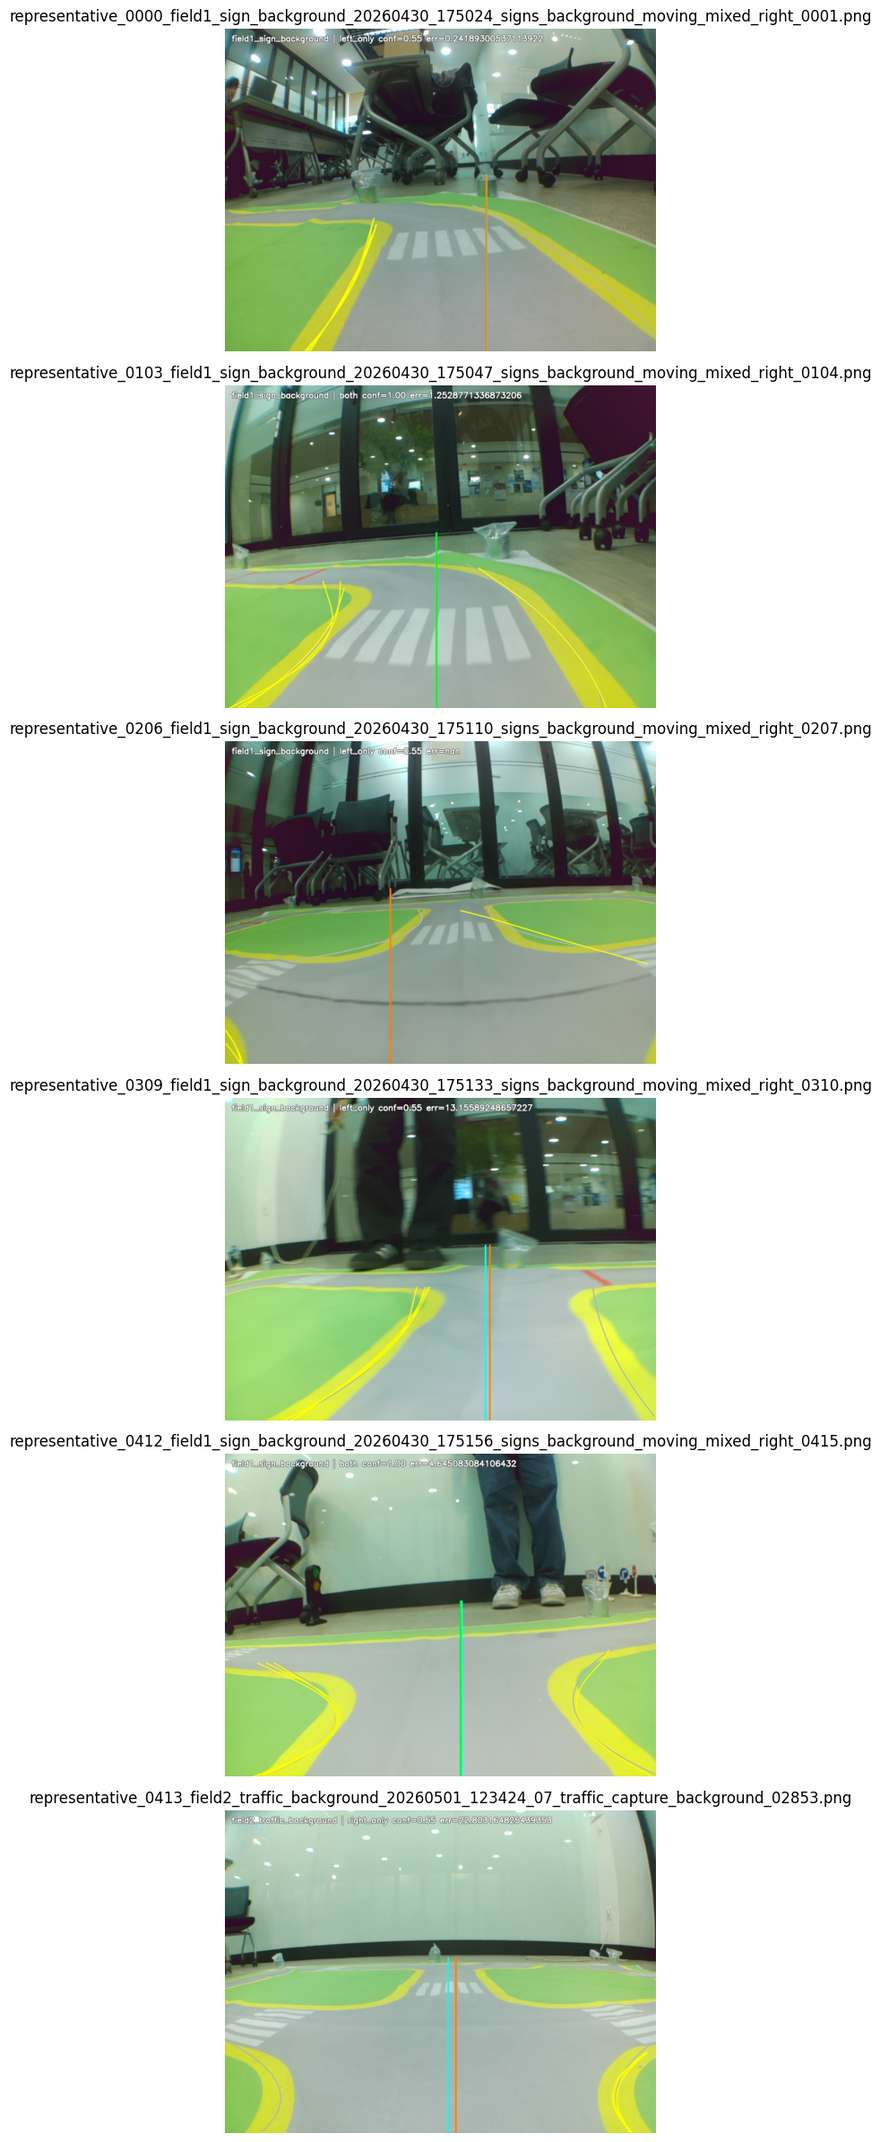

In [13]:
def draw_lane_polyline(img, lane_item, color, thickness=2):
    pts = lane_points(lane_item)
    if len(pts) < 2:
        return
    pts_i = np.round(pts).astype(np.int32).reshape(-1, 1, 2)
    cv2.polylines(img, [pts_i], isClosed=False, color=color, thickness=thickness, lineType=cv2.LINE_AA)


def draw_result_overlay(sample, raw_np, out_path):
    img = cv2_imread_color(sample['img_path'])
    vis = img.copy()
    pred_lanes = decode_raw_numpy(raw_np, DETECTOR_SETTING)
    result = driving_postprocess(pred_lanes, PP_CONFIG, return_debug=True)
    target = gt_target_center(sample)

    for lane in sample['gt']:
        draw_lane_polyline(vis, lane, (180, 180, 180), 2)
    for lane in pred_lanes:
        draw_lane_polyline(vis, lane, (0, 255, 255), 2)

    if np.isfinite(target['center_x']):
        x = int(round(target['center_x']))
        cv2.line(vis, (x, CUT_HEIGHT), (x, RAW_H - 1), (255, 255, 0), 3)
    if np.isfinite(result['center_x']):
        x = int(round(result['center_x']))
        color = (0, 255, 0) if result['mode'] == 'both' else (0, 128, 255)
        cv2.line(vis, (x, CUT_HEIGHT), (x, RAW_H - 1), color, 3)

    text = f"{sample['scene']} | {result['mode']} conf={result['confidence']:.2f} err={abs_center_error(result, target)}"
    cv2.putText(vis, text[:120], (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
    cv2.putText(vis, text[:120], (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    ok, encoded = cv2.imencode('.png', vis)
    if not ok:
        raise RuntimeError(f'failed to encode overlay: {out_path}')
    encoded.tofile(win_long_path(out_path))
    return vis, result, target


sample_df = pd.DataFrame([{'pos': i, 'index': s['index'], 'scene': s['scene'], 'file': Path(s['rel']).name} for i, s in enumerate(samples)])
representative_positions = []
for scene, group in sample_df.groupby('scene'):
    group = group.sort_values('file').reset_index(drop=True)
    idx = np.linspace(0, len(group) - 1, min(5, len(group))).round().astype(int)
    representative_positions.extend(group.iloc[idx]['pos'].astype(int).tolist())

hard_positions = detail_df.sort_values(['abs_center_error_px', 'confidence'], ascending=[False, True]).head(16).index.astype(int).tolist()

overlay_rows = []
for tag, positions in [('representative', representative_positions), ('hard', hard_positions)]:
    for pos in positions:
        sample = samples[pos]
        out_path = OVERLAY_DIR / f'{tag}_{sample["index"]:04d}_{sample["scene"]}_{Path(sample["rel"]).stem}.png'
        _, result, target = draw_result_overlay(sample, onnx_cache['raw_outputs'][pos], out_path)
        overlay_rows.append({
            'tag': tag,
            'sample_index': sample['index'],
            'scene': sample['scene'],
            'file': Path(sample['rel']).name,
            'mode': result['mode'],
            'center_x': result['center_x'],
            'target_center_x': target['center_x'],
            'abs_center_error_px': abs_center_error(result, target),
            'overlay': str(out_path),
        })

overlay_df = pd.DataFrame(overlay_rows)
OVERLAY_INDEX_CSV = TABLE_DIR / 'onnx_overlay_index.csv'
overlay_df.to_csv(win_long_path(OVERLAY_INDEX_CSV), index=False, encoding='utf-8-sig')
display(overlay_df.head(30))
print('saved:', OVERLAY_INDEX_CSV)

show_paths = overlay_df.head(6)['overlay'].tolist()
fig, axes = plt.subplots(len(show_paths), 1, figsize=(13, 4 * len(show_paths)))
if len(show_paths) == 1:
    axes = [axes]
for ax, p in zip(axes, show_paths):
    img = cv2.cvtColor(cv2_imread_color(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(Path(p).name[:140])
plt.tight_layout()
plt.show()

## 12. Local latency 측정

여기서 측정하는 latency는 local CPU 기준이다. Pi 5 latency와 같지는 않다.  
그래도 다음을 분리해서 볼 수 있다.

- preprocess
- ONNX Runtime forward
- official decoder
- driving postprocess

Pi에서는 이 중 ONNX forward가 가장 큰 병목일 가능성이 높다.

In [14]:
latency_positions = evenly_spaced_indices(len(samples), min(20, len(samples)))
latency_tensors = []
for pos in latency_positions:
    img = cv2_imread_color(samples[pos]['img_path'])
    tensor, _ = preprocess_bgr_for_onnx(img)
    latency_tensors.append(tensor)

# warmup
for i in range(LATENCY_WARMUP):
    t = latency_tensors[i % len(latency_tensors)]
    _ = session.run([output_name], {input_name: t})[0]

lat_rows = []
for i in range(LATENCY_RUNS):
    pos = latency_positions[i % len(latency_positions)]
    sample = samples[pos]
    img = cv2_imread_color(sample['img_path'])

    t0 = time.perf_counter()
    tensor, _ = preprocess_bgr_for_onnx(img)
    t1 = time.perf_counter()
    raw_np = session.run([output_name], {input_name: tensor})[0]
    t2 = time.perf_counter()
    lanes = decode_raw_numpy(raw_np, DETECTOR_SETTING)
    t3 = time.perf_counter()
    pred = driving_postprocess(lanes, PP_CONFIG)
    t4 = time.perf_counter()

    lat_rows.append({
        'run': i,
        'sample_index': sample['index'],
        'scene': sample['scene'],
        'preprocess_ms': (t1 - t0) * 1000,
        'onnx_ms': (t2 - t1) * 1000,
        'decode_ms': (t3 - t2) * 1000,
        'postprocess_ms': (t4 - t3) * 1000,
        'total_ms': (t4 - t0) * 1000,
        'mode': pred['mode'],
        'confidence': pred['confidence'],
    })
    if i == 0 or (i + 1) % 25 == 0 or (i + 1) == LATENCY_RUNS:
        print(f'latency {i+1}/{LATENCY_RUNS} total_ms={lat_rows[-1]["total_ms"]:.2f}')

latency_df = pd.DataFrame(lat_rows)
LATENCY_CSV = TABLE_DIR / 'local_onnx_runtime_latency.csv'
latency_df.to_csv(win_long_path(LATENCY_CSV), index=False, encoding='utf-8-sig')

latency_summary = latency_df[['preprocess_ms', 'onnx_ms', 'decode_ms', 'postprocess_ms', 'total_ms']].describe(percentiles=[0.5, 0.9, 0.95])
display(latency_summary)
print('saved:', LATENCY_CSV)

latency 1/100 total_ms=61.92
latency 25/100 total_ms=79.94
latency 50/100 total_ms=77.43
latency 75/100 total_ms=74.55
latency 100/100 total_ms=65.68


,preprocess_ms,onnx_ms,decode_ms,postprocess_ms,total_ms
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.226017,64.346893,2.435019,5.055017,76.062946
std,0.313023,8.074874,1.796869,1.920919,8.536699
min,3.784000,51.181800,0.950100,1.244100,61.569000
50%,4.156150,63.666250,1.898850,4.237500,75.477900
90%,4.578780,68.908130,3.434050,7.720400,81.125970
95%,4.791665,70.592765,3.714485,8.240880,89.591885
max,5.429300,99.634200,17.996200,9.866500,108.069600


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\review_outputs\07_onnx_runtime_validation_and_latency\tables\local_onnx_runtime_latency.csv


## 13. 실행 결과 메모

아직 미실행 상태. 실행 후 아래를 확인하면 된다.

- `actual_image_onnx_pytorch_raw_parity.csv`: 실제 이미지 기준 ONNX/PyTorch raw output 차이
- `onnx_driving_postprocess_summary.csv`: ONNX output을 주행 중심으로 바꿨을 때의 holdout 성능
- `onnx_overlay_index.csv`: representative/hard overlay 이미지 목록
- `local_onnx_runtime_latency.csv`: local CPU 기준 preprocess/ONNX/decode/postprocess latency

판단 기준:

- raw parity가 06 dummy parity와 비슷하게 매우 작으면 ONNX export는 문제 없음.
- driving summary가 05의 best config 결과와 거의 같으면 `ONNX + 공식 decoder + driving postprocess` 연결도 문제 없음.
- overlay에서 초록 중심선이 하늘색 GT 중심선과 대체로 붙어 있으면 Pi preview/dry-run으로 넘어갈 수 있음.
- latency는 local 기준이라 절대값보다 병목 분해용으로 본다. Pi에서 다시 별도 측정해야 함.